# Import Toolekit

In [69]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("darkgrid")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
      recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
)
import joblib

In [70]:
df = pd.read_csv("../assets/classification-model-comparison/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [71]:
df.shape

(7043, 21)

# Preprocessing

In [72]:
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [74]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [75]:
df_clean = df.copy()
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
display(df_clean.isna().sum())



customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [76]:
df_clean.dropna(inplace=True)
df_clean.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [77]:
df_clean = df_clean.drop(columns=["customerID"])
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
churn_counts = df_clean["Churn"].value_counts()
churn_pct = df_clean["Churn"].value_counts(normalize=True) * 100
print("Churn Counts:")
print(churn_counts)
print("\nChurn Percentages:")
print(churn_pct)

Churn Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


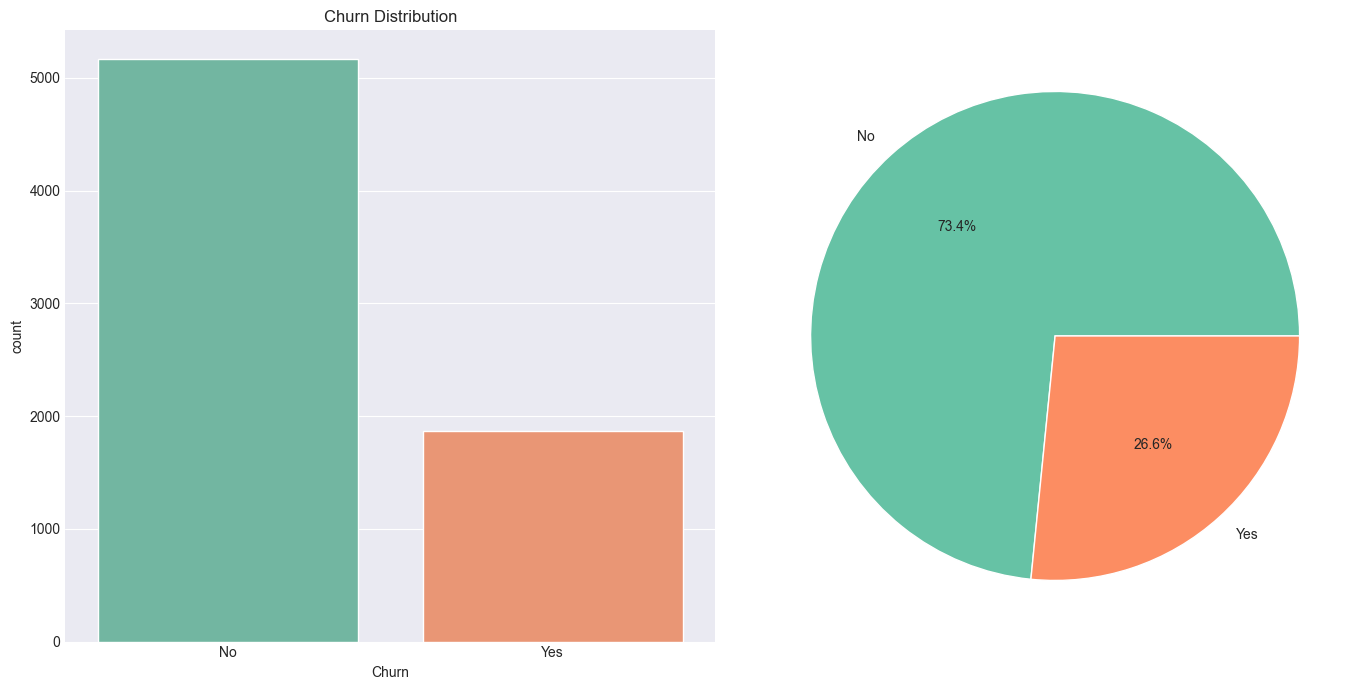

In [79]:
fig , axes = plt.subplots(1,2, figsize=(14,7))
sns.countplot(data=df_clean, x="Churn", ax=axes[0] , palette="Set2")
axes[0].set_title("Churn Distribution")

axes[1].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%", colors=sns.color_palette("Set2"))
plt.tight_layout()
plt.show()

<Axes: xlabel='Churn', ylabel='count'>

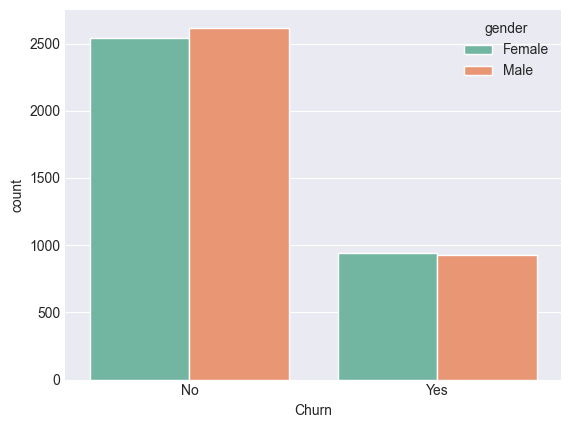

In [80]:
sns.countplot( data = df_clean , x = "Churn" , hue="gender", palette="Set2")

<Axes: xlabel='SeniorCitizen', ylabel='count'>

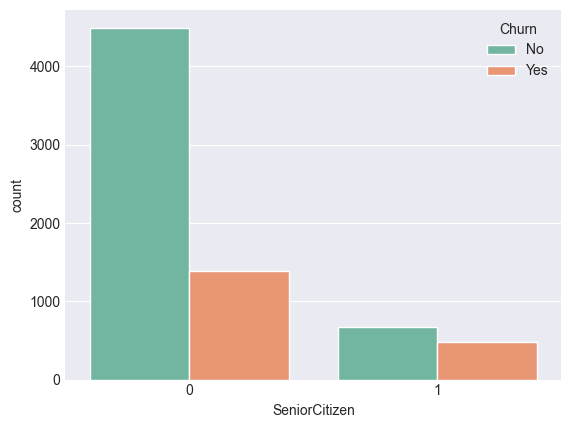

In [81]:
sns.countplot( data = df_clean , x = "SeniorCitizen" , hue="Churn", palette="Set2")

<Axes: xlabel='Contract', ylabel='count'>

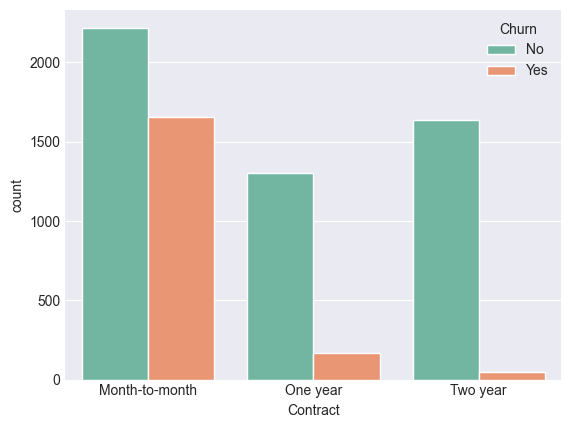

In [82]:
sns.countplot( data = df_clean , x = "Contract" , hue="Churn", palette="Set2")

<Axes: xlabel='InternetService', ylabel='count'>

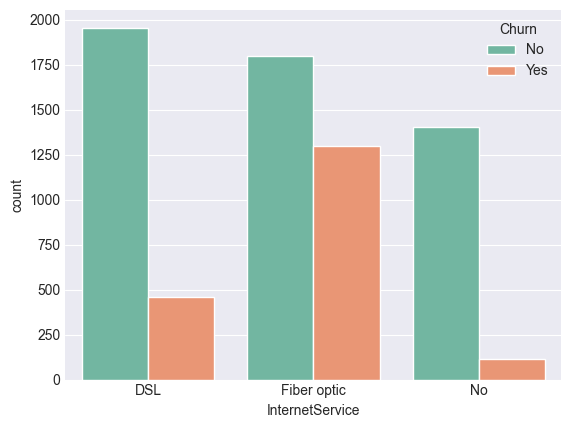

In [83]:
sns.countplot( data = df_clean , x = "InternetService" , hue="Churn", palette="Set2")

<Axes: xlabel='count', ylabel='PaymentMethod'>

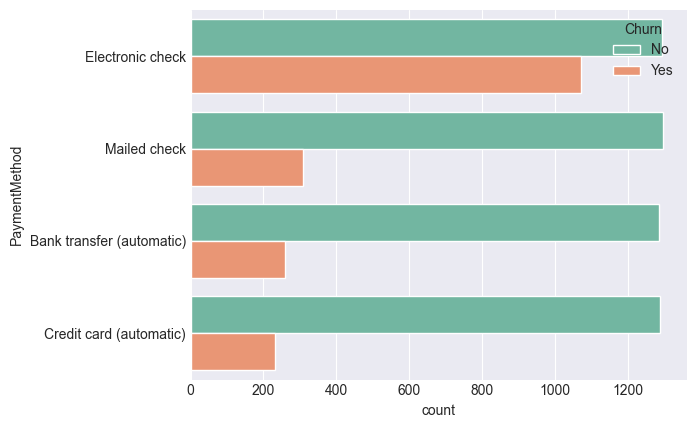

In [84]:
sns.countplot( data = df_clean , y = "PaymentMethod" , hue="Churn", palette="Set2")

In [85]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [86]:
df_preprocess = df_clean.copy()

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_cols:
    df_preprocess[col] = df_preprocess[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

In [87]:
df_preprocess.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [88]:
categorical_cols = df_preprocess.select_dtypes(include=["object"]).columns.to_list()
categorical_cols

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [89]:
df_preprocess =  pd.get_dummies(df_preprocess, columns=categorical_cols, drop_first=True)
df_preprocess.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3090,1,0,0,0,1,1,1,53.50,53.50,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
4135,0,0,1,1,36,1,1,92.90,3379.25,0,False,True,False,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False
149,1,0,1,1,15,1,1,69.50,1071.40,0,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,True
6201,0,1,0,0,5,1,0,80.70,374.80,0,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
5951,0,0,0,0,37,1,0,100.30,3541.40,0,False,True,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,True,False,False
5193,0,0,1,0,72,1,0,26.45,1914.50,0,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,True,False,False
1874,0,0,1,0,43,1,0,86.45,3574.50,0,False,True,False,False,False,True,False,True,False,False,False,True,False,True,False,True,False,True,True,False,False
1379,0,0,0,0,70,0,1,44.60,3058.15,0,True,False,False,False,False,True,False,True,False,True,False,True,False,False,False,False,False,True,False,False,False
6989,0,0,1,1,20,1,0,76.00,1588.75,0,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False
5089,1,0,1,1,8,1,1,54.40,475.10,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False


In [90]:
df_preprocess.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   bool   
 11  MultipleLines_Yes   

In [91]:
x = df_preprocess.drop(columns=["Churn"])
y = df_preprocess["Churn"]

scaler = StandardScaler() 
numeric_cols = [ "tenure", "MonthlyCharges", "TotalCharges"]
x[numeric_cols] = scaler.fit_transform(x[numeric_cols])



In [92]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.512486,0,0,-0.747850,-0.195248,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.239504,1,1,0.196178,-0.940457,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [93]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [94]:
def evaluate_model(model, x_train, x_test, y_train, y_test, model_name="Model"):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    return{
        "Model" : model,
        "Predictions" : y_pred,
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1-Score" : f1,
        "roc_auc_score" : roc_auc

    }

In [95]:
def plot_roc_curve(model, x_test, y_test):
    y_pred_proba = model.predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

In [96]:
def plot_confision_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"],
                linecolor="black", linewidths=2)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.title(f"Confusion Matrix - {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    

### Logistic Regression 

Accuracy : 0.8045
Precision : 0.6495
Recall : 0.5749
F1-Score : 0.6099


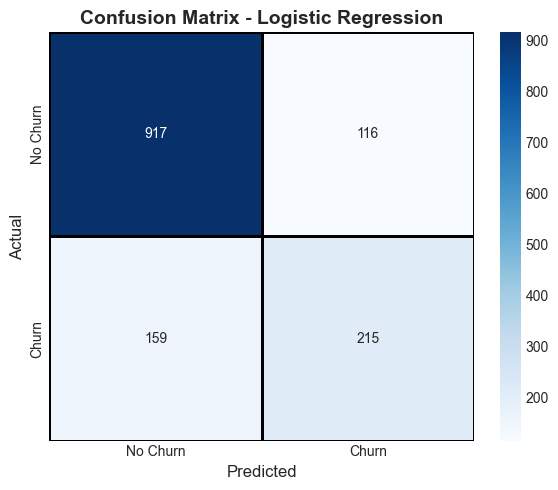

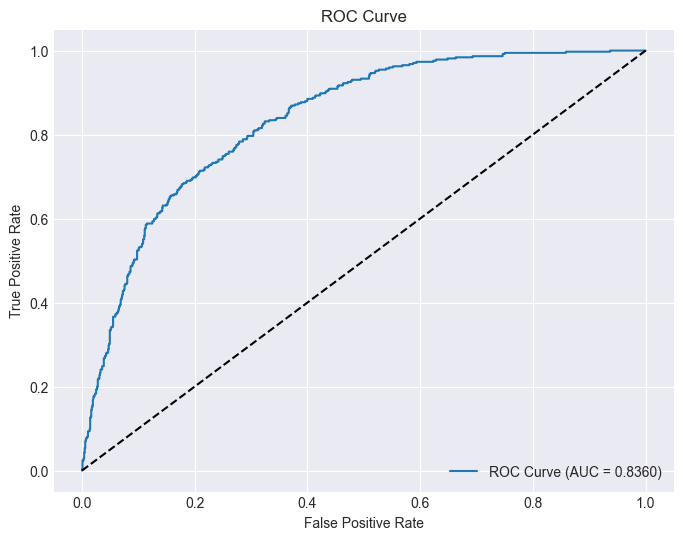

In [97]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_results = evaluate_model(lr_model, x_train, x_test, y_train, y_test, "Logistic Regression")

plot_confision_matrix(y_test, lr_results["Predictions"], "Logistic Regression")
plot_roc_curve(lr_model, x_test, y_test)


### K-Nearest Neighbors

Accuracy : 0.7619
Precision : 0.5496
Recall : 0.5775
F1-Score : 0.5632


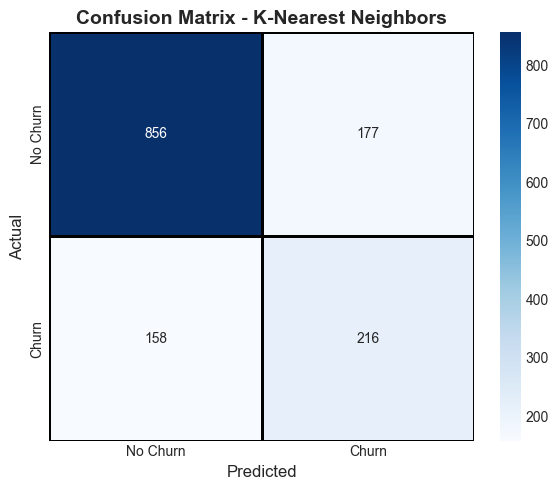

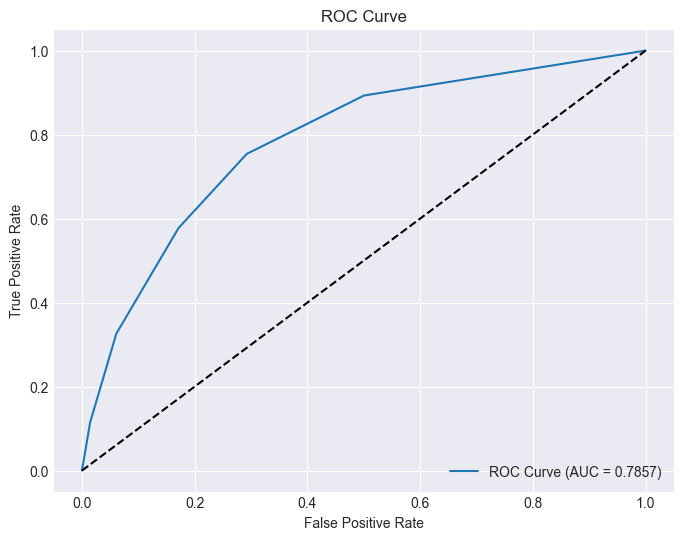

In [98]:
KNN_model = KNeighborsClassifier( n_neighbors=5)
KNN_results = evaluate_model(KNN_model, x_train, x_test, y_train, y_test, "K-Nearest Neighbors")

plot_confision_matrix(y_test, KNN_results["Predictions"], "K-Nearest Neighbors")
plot_roc_curve(KNN_model, x_test, y_test)

### Decision Tree Classifier

Accuracy : 0.7783
Precision : 0.5807
Recall : 0.5963
F1-Score : 0.5884


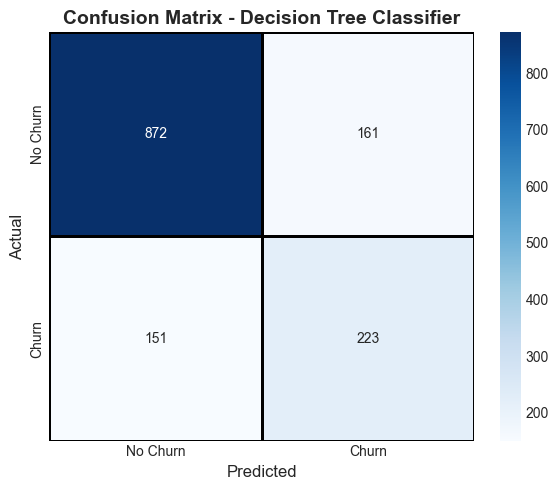

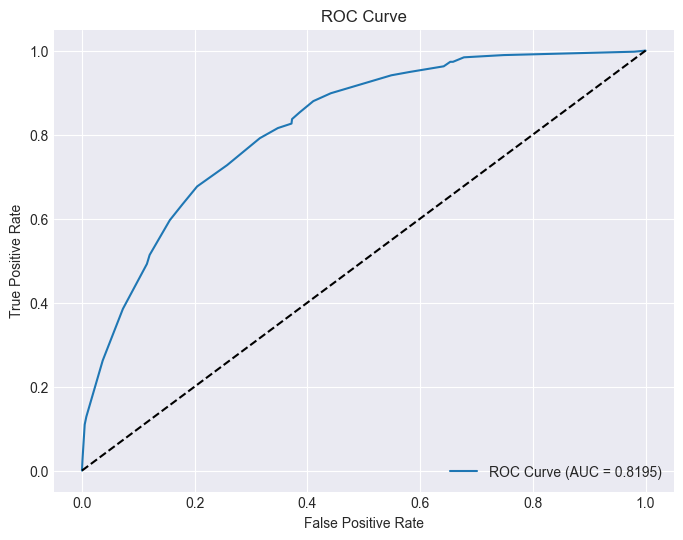

In [99]:
DT_model = DecisionTreeClassifier(random_state=42, max_depth=5)
DT_results = evaluate_model(DT_model, x_train, x_test, y_train, y_test, "Decision Tree Classifier")

plot_confision_matrix(y_test, DT_results["Predictions"], "Decision Tree Classifier")
plot_roc_curve(DT_model, x_test, y_test)

### Random Forest Classifier

Accuracy : 0.7868
Precision : 0.6609
Recall : 0.4064
F1-Score : 0.5033


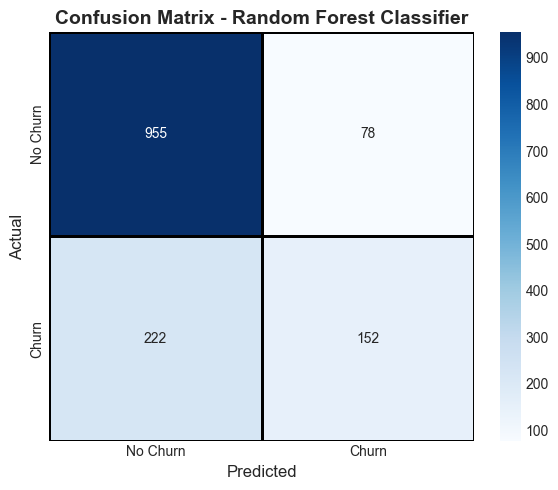

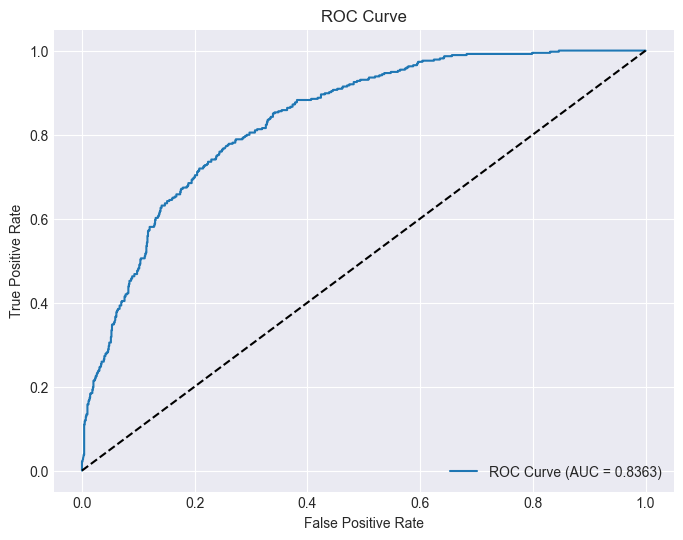

In [100]:
RF_model = RandomForestClassifier(random_state=42, max_depth=5)
RF_results = evaluate_model(RF_model, x_train, x_test, y_train, y_test, "Random Forest Classifier")

plot_confision_matrix(y_test, RF_results["Predictions"], "Random Forest Classifier")
plot_roc_curve(RF_model, x_test, y_test)

### XGBoost Classifier

Accuracy : 0.7783
Precision : 0.5891
Recall : 0.5481
F1-Score : 0.5679


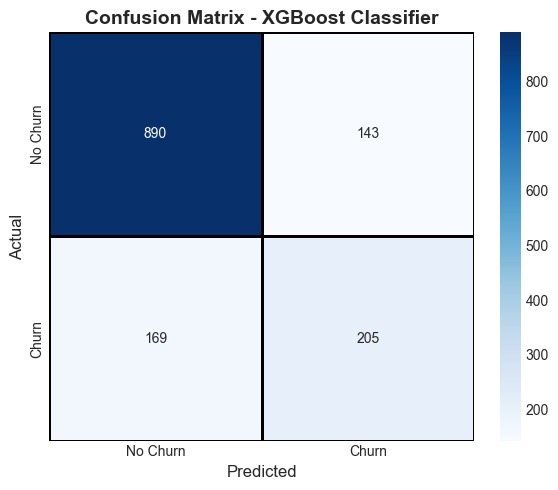

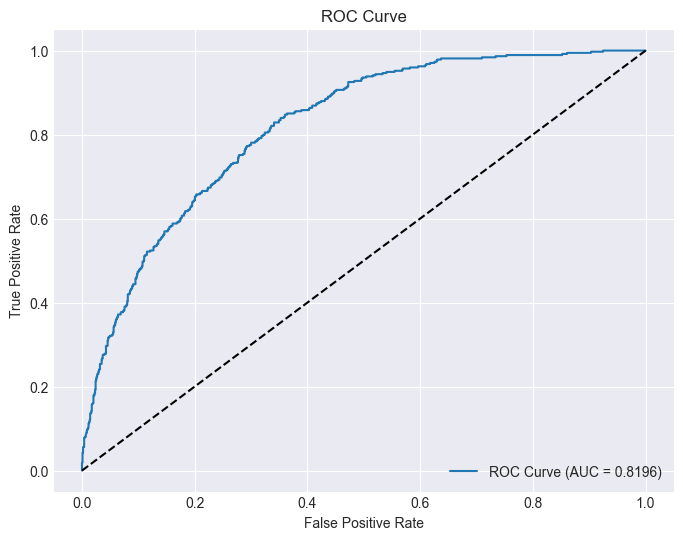

In [101]:
XGB_model = XGBClassifier(random_state=42, eval_metric="logloss")
XGB_results = evaluate_model(XGB_model, x_train, x_test, y_train, y_test, "XGBoost Classifier")

plot_confision_matrix(y_test, XGB_results["Predictions"], "XGBoost Classifier")
plot_roc_curve(XGB_model, x_test, y_test)

In [102]:
results_df = pd.DataFrame({
    "Model" : ["Logistic Regression", "K-Nearest Neighbors",
                "Decision Tree Classifier", "Random Forest Classifier", "XGBoost Classifier"],

    "Accuracy" : [lr_results["Accuracy"], KNN_results["Accuracy"], DT_results["Accuracy"],
                   RF_results["Accuracy"], XGB_results["Accuracy"]],

    "Precision" : [lr_results["Precision"], KNN_results["Precision"], 
                   DT_results["Precision"], RF_results["Precision"], XGB_results["Precision"]],

    "Recall" : [lr_results["Recall"], KNN_results["Recall"], DT_results["Recall"],
                 RF_results["Recall"], XGB_results["Recall"]],

    "F1-Score" : [lr_results["F1-Score"], KNN_results["F1-Score"], DT_results["F1-Score"],
                   RF_results["F1-Score"], XGB_results["F1-Score"]],

    "ROC AUC Score" : [lr_results["roc_auc_score"], KNN_results["roc_auc_score"], DT_results["roc_auc_score"],
                        RF_results["roc_auc_score"], XGB_results["roc_auc_score"]]

})

results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("Model Comparison Results (Sorted by F1-Score):")
print("="*80)
print(results_df.to_string(index=False) )
print("="*80)

results_df.sort_values(by="ROC AUC Score", ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("Model Comparison Results (Sorted by ROC AUC Score):")
print("="*80)
print(results_df.to_string(index=False) )
print("="*80)


Model Comparison Results (Sorted by F1-Score):
                   Model  Accuracy  Precision   Recall  F1-Score  ROC AUC Score
     Logistic Regression  0.804549   0.649547 0.574866  0.609929       0.731286
     K-Nearest Neighbors  0.761905   0.549618 0.577540  0.563233       0.703097
Decision Tree Classifier  0.778252   0.580729 0.596257  0.588391       0.720200
Random Forest Classifier  0.786780   0.660870 0.406417  0.503311       0.665454
      XGBoost Classifier  0.778252   0.589080 0.548128  0.567867       0.704848

Model Comparison Results (Sorted by ROC AUC Score):
                   Model  Accuracy  Precision   Recall  F1-Score  ROC AUC Score
     Logistic Regression  0.804549   0.649547 0.574866  0.609929       0.731286
     K-Nearest Neighbors  0.761905   0.549618 0.577540  0.563233       0.703097
Decision Tree Classifier  0.778252   0.580729 0.596257  0.588391       0.720200
Random Forest Classifier  0.786780   0.660870 0.406417  0.503311       0.665454
      XGBoost Class

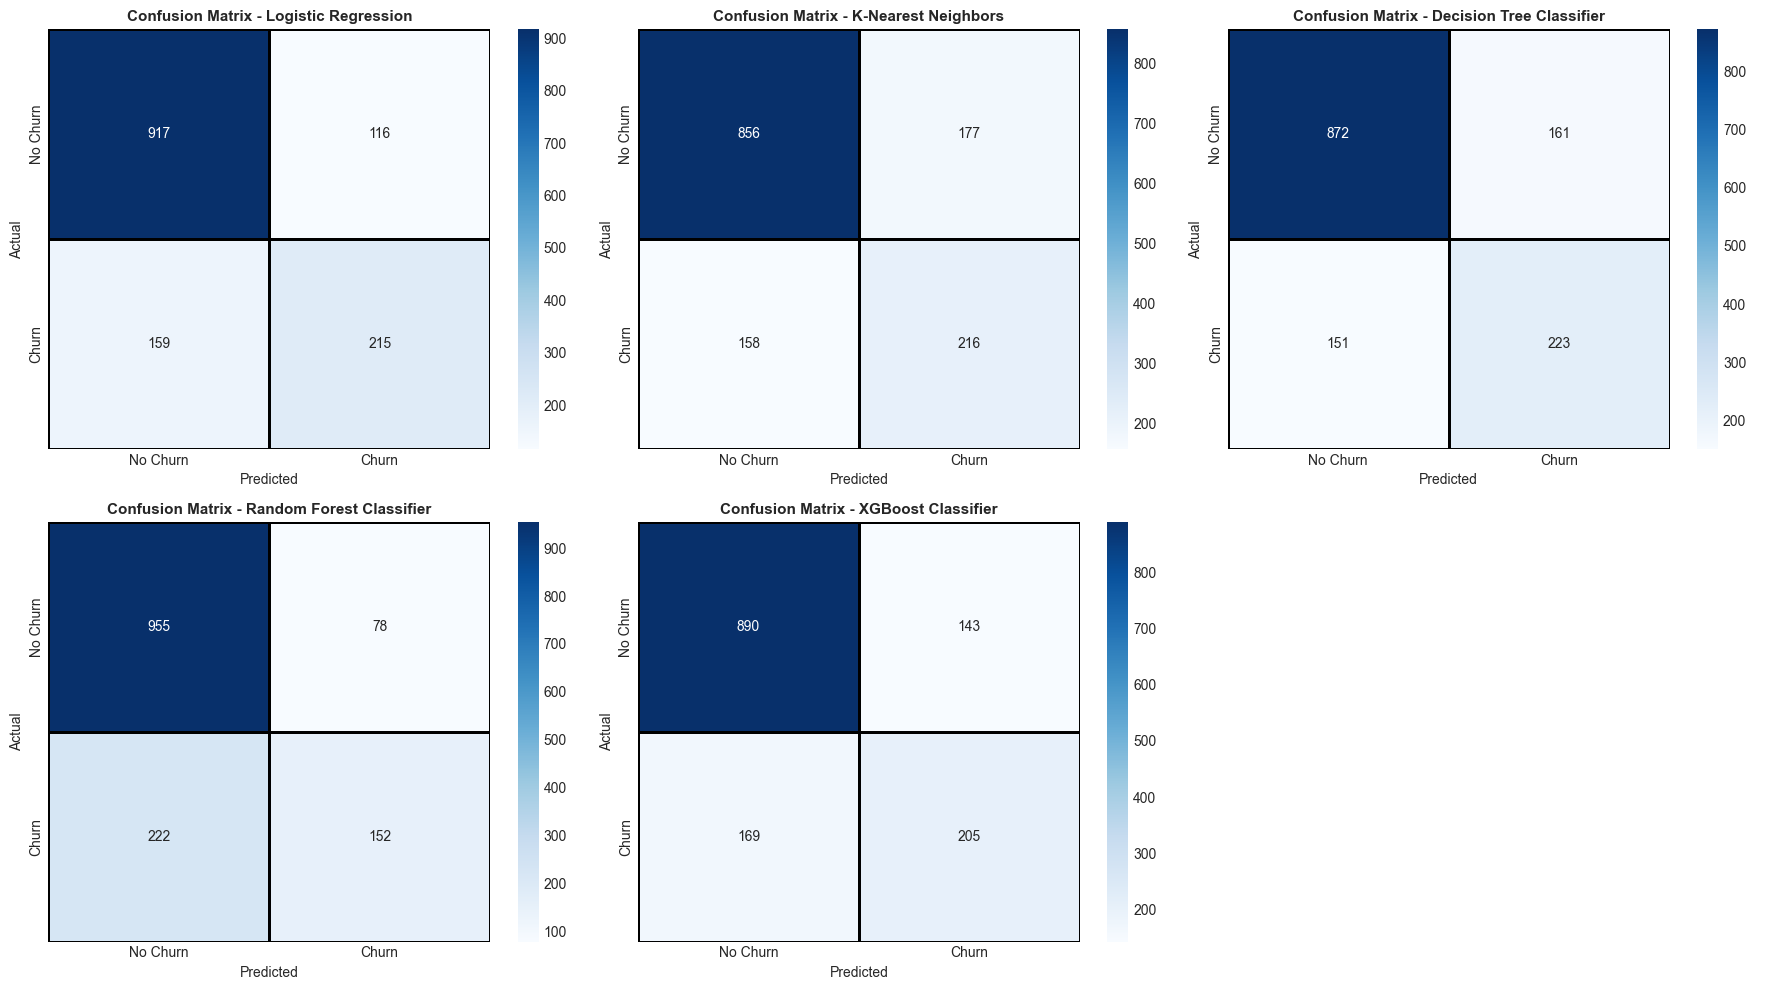

In [103]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

models_data = [
    (y_test, lr_results["Predictions"], "Logistic Regression"),
    (y_test, KNN_results["Predictions"], "K-Nearest Neighbors"),
    (y_test, DT_results["Predictions"], "Decision Tree Classifier"),
    (y_test, RF_results["Predictions"], "Random Forest Classifier"),
    (y_test, XGB_results["Predictions"], "XGBoost Classifier")
]

for idx, (y_true, y_pred, model_name) in enumerate(models_data):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"],
                linecolor="black", linewidths=2, ax=axes[idx])
    axes[idx].set_xlabel("Predicted", fontsize=10)
    axes[idx].set_ylabel("Actual", fontsize=10)
    axes[idx].set_title(f"Confusion Matrix - {model_name}", fontsize=11, fontweight="bold")

axes[-1].axis('off')

plt.tight_layout()
plt.show()

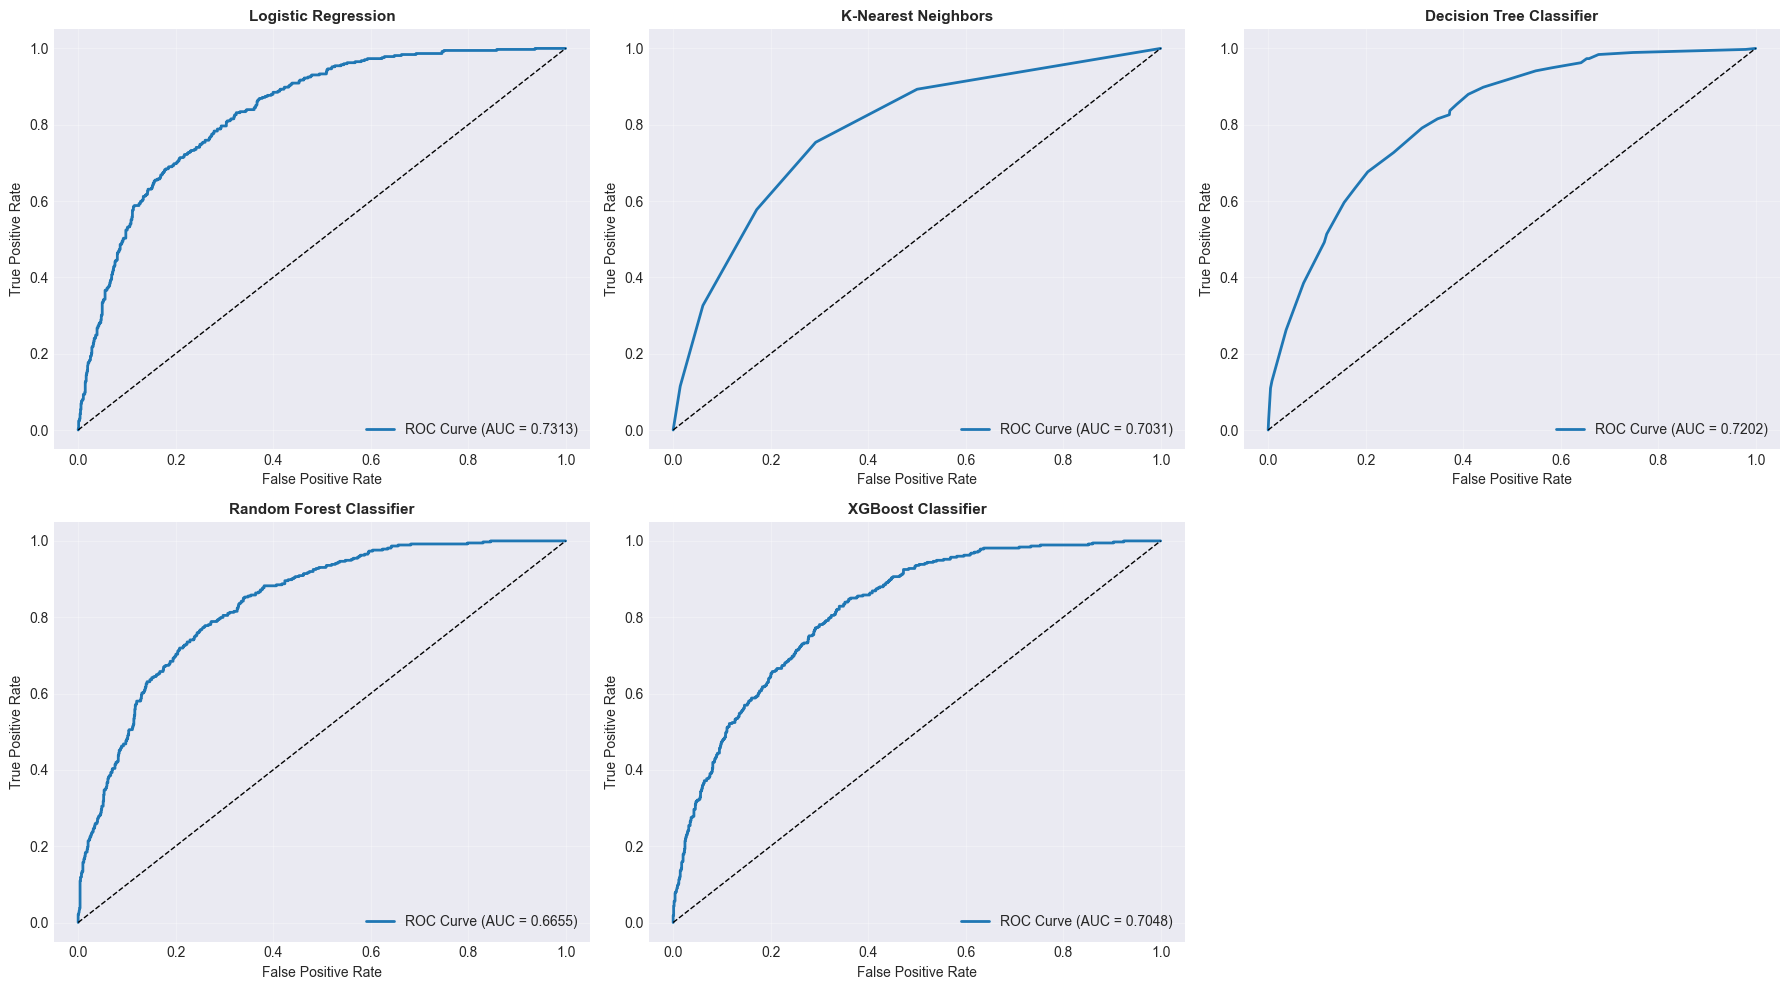

In [104]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

models_info = [
    (lr_model, "Logistic Regression", lr_results["roc_auc_score"]),
    (KNN_model, "K-Nearest Neighbors", KNN_results["roc_auc_score"]),
    (DT_model, "Decision Tree Classifier", DT_results["roc_auc_score"]),
    (RF_model, "Random Forest Classifier", RF_results["roc_auc_score"]),
    (XGB_model, "XGBoost Classifier", XGB_results["roc_auc_score"])
]

for idx, (model, model_name, roc_auc) in enumerate(models_info):
    y_pred_proba = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    axes[idx].plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", linewidth=2)
    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[idx].set_xlabel("False Positive Rate", fontsize=10)
    axes[idx].set_ylabel("True Positive Rate", fontsize=10)
    axes[idx].set_title(model_name, fontsize=11, fontweight="bold")
    axes[idx].legend(loc="lower right")
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [105]:
joblib.dump(XGB_model, "xgb_churn_model.pkl")
joblib.dump(RF_model, "random_forest_model.pkl")
joblib.dump(KNN_model, "knn_model.pkl")
joblib.dump(DT_model, "decision_tree_model.pkl")
joblib.dump(lr_model, "logistic_regression_model.pkl")



['logistic_regression_model.pkl']